## Imports

In [1]:
import numpy as np
import pandas as pd
import kagglehub
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

## Loading data

In [2]:
# Download dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Load CSV
df = pd.read_csv(os.path.join(path, "creditcard.csv"))

print(df.shape)
df.head(5)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Missing Values

In [3]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## Class Distribution

Class
0    284315
1       492
Name: count, dtype: int64


Text(0.5, 1.0, 'Class Distribution (0 = legit, 1 = fraud)')

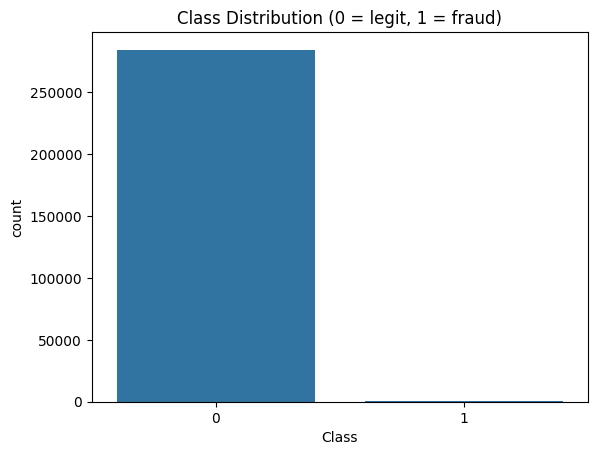

In [4]:
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = legit, 1 = fraud)')

## Class imbalance Visualization

Text(0.5, 1.0, 'Legit Vs Fraud Transactions')

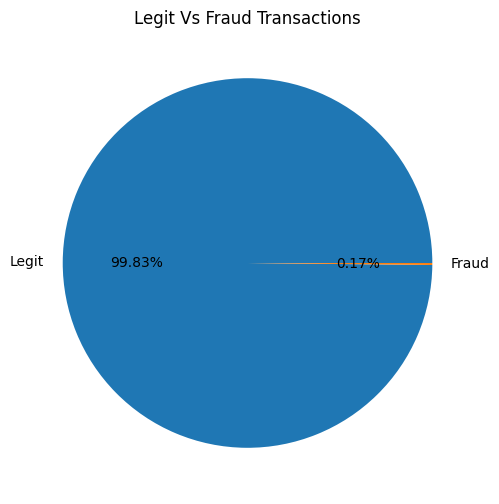

In [5]:
fraud = df['Class'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(fraud, labels=['Legit', 'Fraud'], autopct='%1.2f%%')
plt.title("Legit Vs Fraud Transactions")

## Amount Distribution

Text(0.5, 1.0, 'Transaction Amount Distribution')

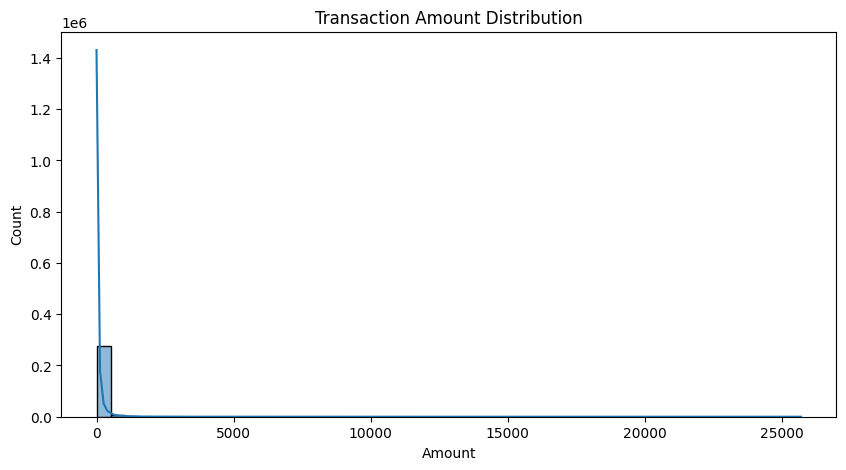

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')

## Fraud vs Amount

Text(0.5, 1.0, 'Amount vs Fraud')

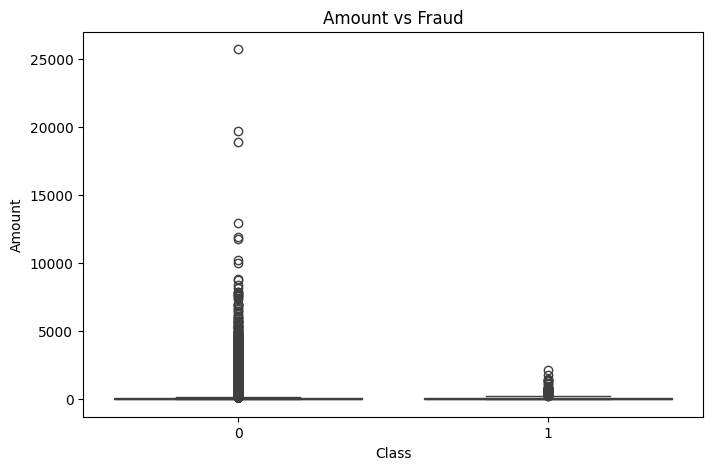

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Fraud")

## Correlation Heatmap (Important)

Text(0.5, 1.0, 'Correlation Heatmap')

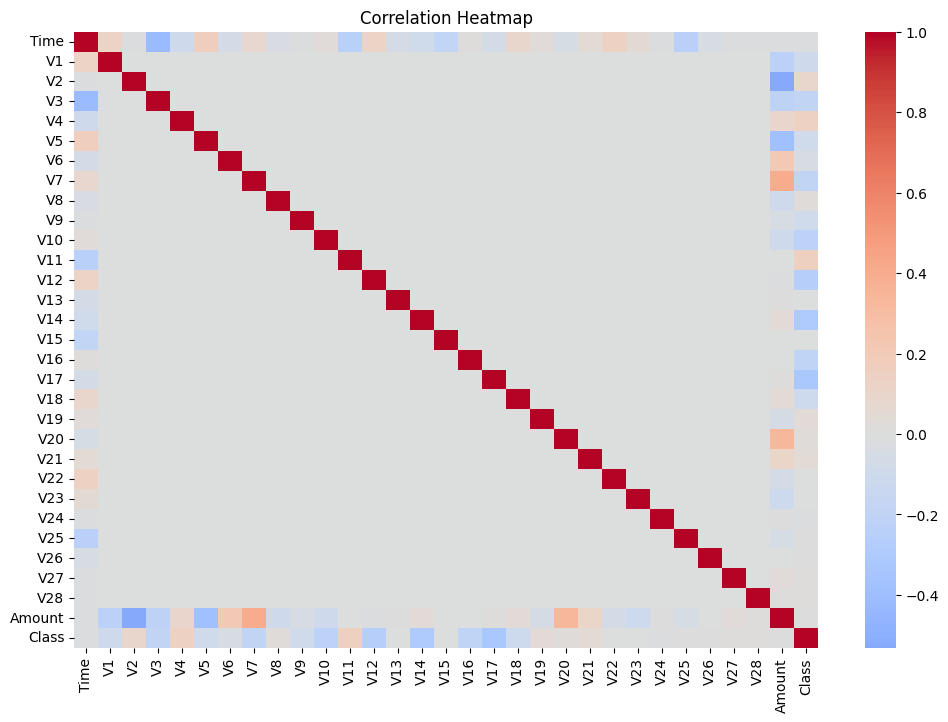

In [8]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

## Feature Engineering

In [9]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

print(type(df))

<class 'pandas.core.frame.DataFrame'>


## Speed Optimization

In [10]:
df = df.sample(frac=0.2, random_state=42)

## Train Test Split

In [11]:
x = df.drop('Class', axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

## Logistic Regression Pipeline

In [12]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=500, solver='saga',n_jobs=-1))
])

## Random Forest Pipeline

In [13]:
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_jobs=-1,random_state=42))
])

## Parameter grid Logistic Regression

In [14]:
lr_param_grid = {
    'clf__C': np.logspace(-4, 3, 8),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear', 'saga'],
    'clf__class_weight': [None, 'balanced']
}

## Parameter grid Random Forest

In [15]:
rf_param_grid = {
    'clf__n_estimators': [100, 150],
    'clf__max_depth': [10, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt'],

    # keep minimal SMOTE tuning
    'smote__k_neighbors': [5],
    'smote__sampling_strategy': [0.5]
}

## Randomized Search

In [16]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_search = RandomizedSearchCV(
    lr_pipeline,
    lr_param_grid,
    n_iter=10,
    scoring='recall',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
    )

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=10,
    scoring='recall',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

## Train Models

In [17]:
lr_search.fit(x_train, y_train)
rf_search.fit(x_train, y_train)

print(f"Best Parameters for Logistic Regression : {lr_search.best_params_}")
print(f"Best Parameters for Random Forest : {rf_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters for Logistic Regression : {'clf__solver': 'liblinear', 'clf__penalty': 'l1', 'clf__class_weight': None, 'clf__C': np.float64(0.0001)}
Best Parameters for Random Forest : {'smote__sampling_strategy': 0.5, 'smote__k_neighbors': 5, 'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}


## Evaluation Function

In [18]:
def evaluate(model, name):
  y_pred = model.predict(x_test)
  y_prob = model.predict_proba(x_test)[:,1]

  print(f'\n====={name}=====')
  print(f'\nConfusion Matrix : \n{confusion_matrix(y_test, y_pred)}')
  print(f'\nClassification Report : \n{classification_report(y_test, y_pred)}')
  print(f'\nROC AUC Score : {roc_auc_score(y_test, y_prob)}')

In [19]:
evaluate(lr_search.best_estimator_, "Logistic Regression")
evaluate(rf_search.best_estimator_, "Random Forest")


=====Logistic Regression=====

Confusion Matrix : 
[[10641   732]
 [    1    19]]

Classification Report : 
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     11373
           1       0.03      0.95      0.05        20

    accuracy                           0.94     11393
   macro avg       0.51      0.94      0.51     11393
weighted avg       1.00      0.94      0.97     11393


ROC AUC Score : 0.9889299217444825

=====Random Forest=====

Confusion Matrix : 
[[11369     4]
 [    4    16]]

Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11373
           1       0.80      0.80      0.80        20

    accuracy                           1.00     11393
   macro avg       0.90      0.90      0.90     11393
weighted avg       1.00      1.00      1.00     11393


ROC AUC Score : 0.9774333948826167


## Threshold Tuning

In [20]:
def threshold_tuning(model, threshold):
  y_prob = model.predict_proba(x_test)[:,1]
  y_pred = (y_prob >= threshold).astype(int)

  print(f'\nThreshold : {threshold}')
  print(f'\nConfusion Matrix : \n{confusion_matrix(y_test, y_pred)}')
  print(f'\nClassification Report : \n{classification_report(y_test, y_pred)}')

threshold_tuning(rf_search.best_estimator_, 0.3)


Threshold : 0.3

Confusion Matrix : 
[[11362    11]
 [    1    19]]

Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11373
           1       0.63      0.95      0.76        20

    accuracy                           1.00     11393
   macro avg       0.82      0.97      0.88     11393
weighted avg       1.00      1.00      1.00     11393



ROC Curve

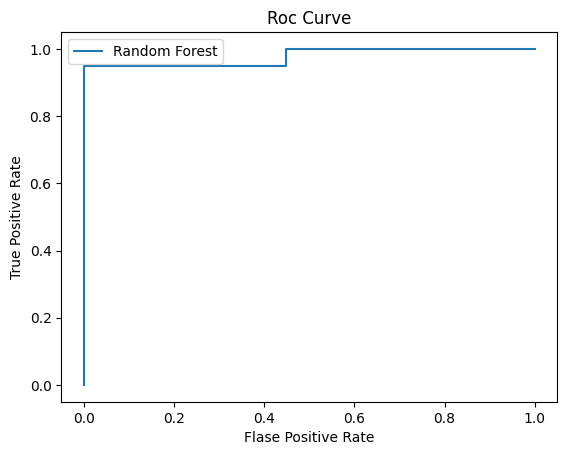

In [21]:
model = rf_search.best_estimator_
y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel('Flase Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc Curve')
plt.legend()
plt.show()

## Precision-Recall Curve

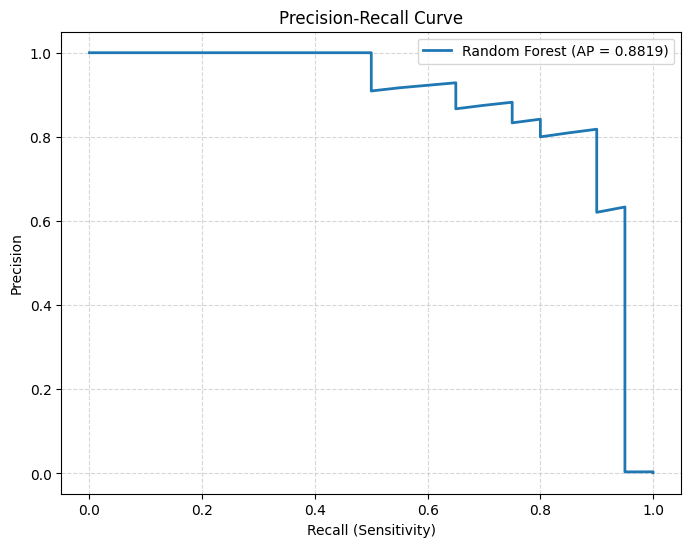

In [22]:
# Get predicted probabilities
y_prob = rf_search.best_estimator_.predict_proba(x_test)[:, 1]

# Compute Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Average Precision Score (important metric)
avg_precision = average_precision_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, lw=2, label=f'Random Forest (AP = {avg_precision:.4f})')

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()